# PARTICIPANT 5

This script processes environmental monitoring data collected from various sources including Eltek, bathroom sensors, bedroom CO2 sensors, weather data, and noise sensors. The script cleans, merges, and calibrates this data to create a consolidated dataset. Additionally, it identifies and handles issues in the data (e.g., sensor errors) and prepares the data for further analysis.

**Notes about campaign:**
1. Issues with outdoor unit
2. Looks like bathroom1 sensor installed 20/01/21
3. Moved event sensor to front door 5/3/21
4. Change over battery on 05/03/2021
5. Noise equipment swapped - was unit 005, now 008. 14/04/2021
6. Equipment uninstalled 21.06.2021
7. Bedroom 2 event sensor missing

## Import Packages and Functions

In [21]:
# -*- coding: utf-8 -*-
#!/usr/bin/python

import os

# run shared function notebooks to load all functions
%run functions.ipynb
%run plotting_functions.ipynb

Packages loaded.

All functions have been defined.


## Load Eltek Data

Load environmental data from the Eltek AQ110a sensor system.

**Sensor Configuration:**
- AQ110A EI130855 T-32656: Outside
- AQ110A EI130895 T-32672: Kitchen
- AQ110A EI130887 T-32658: Living Room
- GD47AC EI130994 T-36249: Main bedroom
- GD47AC EI130997 T-36244: Second bedroom

**Sensor IDs:** 32656, 32672, 32658, 36249, 36244

In [22]:
p5_eltek = ingest_aq110a(path = '../data/p5_central_london_flat/data_unprocessed/K01830-12194.csv'
                     , import_variables = ['', 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc',
                                           'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc',
                                           'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc',
                                           'temperature', 'humidity', 'co2',
                                           'temperature', 'humidity', 'co2']
                     , column_names = ['external_temperature', 'external_humidity', 'external_co2', 'external_1um', 'external_25um', 'external_100um', 'external_airflow', 'external_no2', 'external_co1', 'external_voc',
                                       'kitchen_temperature', 'kitchen_humidity', 'kitchen_co2', 'kitchen_1um', 'kitchen_25um', 'kitchen_100um', 'kitchen_airflow', 'kitchen_no2', 'kitchen_co1', 'kitchen_voc',
                                       'living_temperature', 'living_humidity', 'living_co2', 'living_1um', 'living_25um', 'living_100um', 'living_airflow', 'living_no2', 'living_co1', 'living_voc',
                                       'bedroom1_temperature', 'bedroom1_humidity', 'bedroom1_co2',
                                       'bedroom2_temperature', 'bedroom2_humidity', 'bedroom2_co2']
                     , convert_no2 = True
                     , convert_co = True
                     , input_interpolate = True
                     , input_iterpolate_limit = 6
                     )

# delete external temp and rh
del p5_eltek['external_temperature']
del p5_eltek['external_humidity']

# baseline co1 and no2
aq110a_no2_co1_baseline (input_dataframe = p5_eltek
                             , input_percentile = 5)


---------------------------------------------
Ingesting AQ110a data from ../data/p5_central_london_flat/data_unprocessed/K01830-12194.csv


/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_10231/1228987109.py:59: DtypeWarning: Columns (1,2,4,5,6,7,8,9,11,12,13,14,15,17,18,19,21,22,23,24,27,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  eltek = pd.read_csv(path, skiprows = 3) # ingest



Correction

-----------------------
32656_temperature
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_humidity
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_co2
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_1um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_25um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_100um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_airflow
baseline_correction

False


## Load Bathroom 1 Data

Load bathroom 1 temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments:**
- First: EI130474
- Second: EI130509
- Third: EI130500

In [23]:
#### bathroom 1 - file 1
p5_bathroom1_1 = ingest_u12_012('../data/p5_central_london_flat/data_unprocessed/210608_EI130474.csv'
                      , 0
                      , ['date', 'time', 'bathroom1_temperature', 'bathroom1_humidity', 'bathroom1_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130474'
                      )

#### bathroom 1 - file 2
p5_bathroom1_2 = ingest_u12_012('../data/p5_central_london_flat/data_unprocessed/210608_EI130509.csv'
                      , 0
                      , ['date', 'time', 'bathroom1_temperature', 'bathroom1_humidity', 'bathroom1_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130509'
                      )

#### bathroom 1 - file 3
p5_bathroom1_3 = ingest_u12_012('../data/p5_central_london_flat/data_unprocessed/210622_EI130500.csv'
                      , 0
                      , ['date', 'time', 'bathroom1_temperature', 'bathroom1_humidity', 'bathroom1_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130500'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p5_central_london_flat/data_unprocessed/210608_EI130474.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bathroom1_temperature    0
bathroom1_humidity       0
bathroom1_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p5_central_london_flat/data_unprocessed/210608_EI130509.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 bathroom1_temperature    0
bathroom1_humidity       0
b

## Join Bathroom 1 Data

Concatenate bathroom 1 data from different time periods:
- File 1: beginning to 2021-03-05 12:00
- File 2: 2021-03-05 12:05 to 2021-05-23 21:00
- File 3: 2021-05-23 21:05 to 2021-06-22 10:20

In [24]:
#### join all bathroom 1
p5_bathroom1_1 = p5_bathroom1_1.loc[:'2021-03-05 12:00:00']
p5_bathroom1_2 = p5_bathroom1_2.loc['2021-03-05 12:05:00':'2021-05-23 21:00:00']
p5_bathroom1_3 = p5_bathroom1_3.loc['2021-05-23 21:05:00':'2021-06-22 10:20:00']
p5_dfs = [p5_bathroom1_1, p5_bathroom1_2, p5_bathroom1_3]
p5_bathroom1 = pd.concat(p5_dfs)
p5_bathroom1 = p5_bathroom1.resample('5T').ffill() # resample and backfill for 5 mins
del p5_bathroom1_1, p5_bathroom1_2, p5_bathroom1_3
p5_bathroom1 = p5_bathroom1.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_10231/2422944071.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p5_bathroom1 = p5_bathroom1.resample('5T').ffill() # resample and backfill for 5 mins


## Load Bathroom 2 Data

Load bathroom 2 temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments:**
- First: EI130264
- Second: EI130556 (EI130514 - bathroom 3 - not used)
- Third: EI130446

In [25]:
#### bathroom 2 - file 1
p5_bathroom2_1 = ingest_u12_012('../data/p5_central_london_flat/data_unprocessed/210608_EI130264.csv'
                      , 0
                      , ['date', 'time', 'bathroom2_temperature', 'bathroom2_humidity', 'bathroom2_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130264'
                      )

#### bathroom 2 - file 2
p5_bathroom2_2 = ingest_u12_012('../data/p5_central_london_flat/data_unprocessed/210608_EI130556.csv'
                      , 0
                      , ['date', 'time', 'bathroom2_temperature', 'bathroom2_humidity', 'bathroom2_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130556'
                      )

#### bathroom 2 - file 3
p5_bathroom2_3 = ingest_u12_012('../data/p5_central_london_flat/data_unprocessed/210622_EI130446.csv'
                      , 0
                      , ['date', 'time', 'bathroom2_temperature', 'bathroom2_humidity', 'bathroom2_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130446'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p5_central_london_flat/data_unprocessed/210608_EI130264.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bathroom2_temperature    0
bathroom2_humidity       0
bathroom2_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p5_central_london_flat/data_unprocessed/210608_EI130556.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 bathroom2_temperature    0
bathroom2_humidity       0
b

## Join Bathroom 2 Data

Concatenate bathroom 2 data from different time periods.

In [26]:
#### join all bathroom 2
p5_bathroom2_1 = p5_bathroom2_1.loc[:'2021-03-05 12:00:00']
p5_bathroom2_2 = p5_bathroom2_2.loc['2021-03-05 12:05:00':'2021-05-23 12:00:00']
p5_bathroom2_3 = p5_bathroom2_3.loc['2021-05-23 12:05:00':]
p5_dfs = [p5_bathroom2_1, p5_bathroom2_2, p5_bathroom2_3]
p5_bathroom2 = pd.concat(p5_dfs)
p5_bathroom2 = p5_bathroom2.resample('5T').ffill() # resample and backfill for 5 mins
del p5_bathroom2_1, p5_bathroom2_2, p5_bathroom2_3, p5_dfs
p5_bathroom2 = p5_bathroom2.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_10231/1569845587.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p5_bathroom2 = p5_bathroom2.resample('5T').ffill() # resample and backfill for 5 mins


## Merge Eltek and Bathroom Data

In [27]:


p5_dfs = [p5_eltek, p5_bathroom1, p5_bathroom2] # create a list with all p5_dfs to be merged
p5 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p5_dfs) # merge
p5 = p5.sort_index() # sort by index
#### clean-up
del p5_dfs, p5_eltek, p5_bathroom1, p5_bathroom2
p5.isna().sum() #should equal 0
p5.duplicated()
p5 = p5.sort_values(by=['date'])

## Import Event Data

Load window and door event data from UX90-001M sensors.

**Sensors:**
- EI130834: balcony_door
- EI1305805: main_door
- EI130840: bedroom1_window
- EI130823: bedroom2_window - **MISSING WHEN COLLECTED**
- EI130800: living_window

In [28]:


"""
EI130834 - balcony_door
EI1305805 - main_door
EI130840 - bedroom1_window
EI130823 - bedroom2_window - **MISSING WHEN I WENT TO COLLECT**
EI130800 - living_window
"""


p5_event_dict = ingest_ux90_001m_group_new(input_file_list =
                           ['../data/p5_central_london_flat/data_unprocessed/210622_EI130834.csv'
                            , '../data/p5_central_london_flat/data_unprocessed/210622_EI130805.csv'
                            , '../data/p5_central_london_flat/data_unprocessed/210622_EI130840.csv'
                            , '../data/p5_central_london_flat/data_unprocessed/210622_EI130800.csv'
                           ]
                       , input_output_name_list =
                           ['balcony_door_event'
                            , 'main_door_event'
                            ,'bedroom1_window_event'
                            , 'living_window_event'
                            ]
                       , input_skiprows = 0
                       , input_main_dataframe = p5
                       )

event_durations(input_event_dict = p5_event_dict)
p5_event_dict['main_door_event'] = p5_event_dict['main_door_event'].set_index(p5_event_dict['main_door_event']['date'])
#### list of all events
p5_event_list = event_list_function(input_event_dict = p5_event_dict)


---------------------------------------------
Ingesting ux90_001m data from ../data/p5_central_london_flat/data_unprocessed/210622_EI130834.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p5_central_london_flat/data_unprocessed/210622_EI130805.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p5_central_london_flat/data_unprocessed/210622_EI130840.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p5_central_london_flat/data_unprocessed/210622_EI130800.csv
balcony_door_event

main_door_event

bedroom1_window_event

living_window_event

balcony_door_event
main_door_event
bedroom1_window_event
living_window_event


## Import Weather Data

Load external weather data from CEDA.

In [29]:
p5_weather = ingest_ceda_weather_data(input_path = '../data/p5_central_london_flat/data_unprocessed/weather.csv'
                         , skiprows = 0
                         , cols_from_ceda = ['ob_time', ' wind_direction', ' wind_speed', ' air_temperature', ' dewpoint', ' wetb_temp', ' alt_pres', ' rltv_hum']
                         , new_col_names = ['date', 'external_wind_direction', 'external_wind_speed', 'external_temperature', 'external_dewpoint', 'external_wetb_temp', 'external_alt_pres', 'external_humidity']
                         )


---------------------------------------------
Ingesting weather data from ../data/p5_central_london_flat/data_unprocessed/weather.csv
nans before interpolating =  external_wind_direction    515
external_wind_speed          0
external_temperature         0
external_dewpoint            0
external_wetb_temp           0
external_alt_pres            3
external_humidity            0
dtype: int64
nans before interpolating =  external_wind_direction    0
external_wind_speed        0
external_temperature       0
external_dewpoint          0
external_wetb_temp         0
external_alt_pres          0
external_humidity          0
dtype: int64
Weather data ingested


## Import Raspberry Pi Noise Data

Load and process noise measurement data from Raspberry Pi microphones.

**Unit Swap:**
- Unit 5 end: 23:55 on 13/04/2021
- Unit 8 start: 10:35 on 14/04/2021

In [30]:
p5_noise_dict, p5_noise_inside, p5_noise_outside =  rpi_noise_ingest(input_start_directory = '../data/p5_central_london_flat/data_unprocessed/noise/')
####    joining the two noise unit data together
p5_unit5_in = p5_noise_dict['PHEUCLio005', 'in']
p5_unit5_out = p5_noise_dict['PHEUCLio005', 'out']
p5_unit8_in = p5_noise_dict['PHEUCLio008', 'in']
p5_unit8_out = p5_noise_dict['PHEUCLio008', 'out']
"""
Filter:
Unit 5 end = 23:55 on 13/04/2021
Unit 8 start = 10:35 14/04/2021
"""
p5_unit5_in = p5_unit5_in.sort_index()
p5_unit5_in = p5_unit5_in.loc['2021-02-23 09:55:00':'2021-04-13 23:55:00']
p5_unit5_out = p5_unit5_out.sort_index()
p5_unit5_out = p5_unit5_out.loc['2021-02-23 09:55:00':'2021-04-13 23:55:00']

p5_unit8_in = p5_unit8_in.sort_index()
p5_unit8_in = p5_unit8_in.loc['2021-04-14 10:35:00':'2021-06-20 23:55:00']
p5_unit8_out = p5_unit8_out.sort_index()
p5_unit8_out = p5_unit8_out.loc['2021-04-14 10:35:00':'2021-06-20 23:55:00']

p5_dfs = [p5_unit5_in, p5_unit8_in]
p5_noise_inside = pd.concat(p5_dfs)
p5_noise_inside = p5_noise_inside.resample('5T').ffill() # resample and backfill for 5 mins

p5_dfs = [p5_unit5_out, p5_unit8_out]
p5_noise_outside = pd.concat(p5_dfs)
p5_noise_outside = p5_noise_outside.resample('5T').ffill() # resample and backfill for 5 mins

del p5_noise_inside['unit']
del p5_noise_outside['unit']

del p5_noise_inside['mic']
del p5_noise_outside['mic']

#### calculate differences
cols = list(p5_noise_inside.columns)
p5_noise_differences = pd.DataFrame()

for freq in cols:
    print(freq)
    p5_noise_differences[freq] = p5_noise_outside[freq] - p5_noise_inside[freq]

p5_noise_differences = p5_noise_differences.add_prefix('difference_') # add prefix to all columns

p5_noise_inside = p5_noise_inside.add_prefix('inside_') # add prefix to all columns
p5_noise_inside.rename(columns={'inside_date': 'date'}, inplace=True)
p5_noise_outside = p5_noise_outside.add_prefix('outside_') # add prefix to all columns
p5_noise_outside.rename(columns={'outside_date': 'date'}, inplace=True)

del p5_dfs, p5_unit5_in, p5_unit5_out, p5_unit8_in, p5_unit8_out, cols, freq

leq
laeq
25hz
31.5hz
40hz
50hz
63hz
80hz
100hz
125hz
160hz
200hz
250hz
315hz
400hz
500hz
630hz
800hz
1000hz
1250hz
1600hz
2000hz
2500hz
3150hz
4000hz
5000hz
6300hz
8000hz
10000hz


/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_10231/512365195.py:24: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p5_noise_inside = p5_noise_inside.resample('5T').ffill() # resample and backfill for 5 mins
/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_10231/512365195.py:28: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p5_noise_outside = p5_noise_outside.resample('5T').ffill() # resample and backfill for 5 mins


## Merge Noise Data into Main DataFrame

In [31]:
p5['external_noise'] = p5_noise_outside['outside_laeq']
p5['living_inside_dba'] = p5_noise_inside['inside_laeq']
del p5_noise_inside, p5_noise_outside, p5_noise_differences

## Import Occupancy Data

Load occupancy sensor data from UX90-006 sensors.

**Sensors:**
- 20425583: Bedroom 1
- 20425587: Bedroom 2
- 20425581: Living
- 20425584: Not used!! **FOUND IN BOX WHEN UNINSTALLED**
- 20608904: Hallway

In [32]:
"""
20425583	Bedroom 1
20425587	Bedroom 2
20425581	Living
20425584	Not used!! ** FOUND IN BOX WHEN UNINSTALLED**
20608904	Hallway
"""

p5_occupancy_dict = ingest_ux90_006_group(input_file_list = ['../data/p5_central_london_flat/data_unprocessed/210622_20425583.csv'
                                                          , '../data/p5_central_london_flat/data_unprocessed/210622_20425587.csv'
                                                          , '../data/p5_central_london_flat/data_unprocessed/210622_20425581.csv'
                                                          , '../data/p5_central_london_flat/data_unprocessed/210622_20608904.csv']
                                                          , output_name_list = ['bedroom1_occupancy', 'bedroom2_occupancy','living_occupancy', 'hallway_occupancy']
                                                          , skiprows = 0
                                                          )


---------------------------------------------
Ingesting ux90_006 data from ../data/p5_central_london_flat/data_unprocessed/210622_20425583.csv
Non-unique observations =  0
                    date  bedroom1_occupancy
0    2021-03-10 11:00:00                 0.0
1    2021-03-12 18:17:33                 1.0
2    2021-03-12 18:38:42                 0.0
3    2021-03-12 18:58:32                 1.0
4    2021-03-13 01:24:25                 0.0
...                  ...                 ...
3570 2021-06-22 07:45:38                 0.0
3571 2021-06-22 08:48:45                 1.0
3572 2021-06-22 09:08:33                 0.0
3573 2021-06-22 09:10:45                 1.0
3574 2021-06-22 09:32:02                 1.0

[3575 rows x 2 columns]
ux90_006 data ingested
---------------------------------------------


---------------------------------------------
Ingesting ux90_006 data from ../data/p5_central_london_flat/data_unprocessed/210622_20425587.csv
Non-unique observations =  0
                   

## Merge Weather Data and Reorganize DataFrame

In [33]:
p5_dfs = [p5, p5_weather]
p5 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p5_dfs)
p5 = p5.sort_values(by=['date'])
del p5_weather, p5_dfs
p5 = p5.reindex(sorted(p5.columns), axis=1)
p5 = p5.sort_values(by=['date'])

## Create Room and Variable Dictionary

Generate a dictionary organizing all measured variables by room.

In [34]:
p5_variable_list = ['temperature',
             'humidity',
             'co2',
             '1um',
             '25um',
             '100um',
             'airflow',
             'no2',
             'co1',
             'voc',
             'light'
             ]

p5_rooms_and_variables = rooms_variables_dict(input_dataframe = p5
                      ,variables = p5_variable_list)

# manually add noise to living room
# inside_dba
p5_rooms_and_variables['living'].append('inside_dba')

external




['100um', '1um', '25um', 'airflow', 'alt_pres', 'co1', 'co2', 'dewpoint', 'humidity', 'no2', 'noise', 'temperature', 'voc', 'wetb_temp', 'wind_direction', 'wind_speed']
bathroom2




['humidity', 'light', 'temperature']
bathroom1




['humidity', 'light', 'temperature']
bedroom2




['co2', 'humidity', 'temperature']
bedroom1




['co2', 'humidity', 'temperature']
living




['100um', '1um', '25um', 'airflow', 'co1', 'co2', 'humidity', 'inside_dba', 'no2', 'temperature', 'voc']
kitchen




['100um', '1um', '25um', 'airflow', 'co1', 'co2', 'humidity', 'no2', 'temperature', 'voc']


## Create Room and Event Dictionary

Define which events are associated with each room.

In [35]:
p5_rooms_list = ['living', 'kitchen', 'bathroom1', 'bathroom2', 'bedroom1', 'bedroom2']
p5_living_events = ['living_window_event', 'balcony_door_event']
p5_kitchen_events = ['living_window_event', 'balcony_door_event']
p5_bedroom1_events = ['bedroom1_window_event']
p5_bedroom2_events = []
p5_bathroom1_events = []
p5_bathroom2_events = []

p5_rooms_and_events = {}
p5_rooms_and_events['living'] = p5_living_events
p5_rooms_and_events['kitchen'] = p5_kitchen_events
p5_rooms_and_events['bedroom1'] = p5_bedroom1_events
p5_rooms_and_events['bedroom2'] = p5_bedroom2_events
p5_rooms_and_events['bathroom1'] = p5_bathroom1_events
p5_rooms_and_events['bathroom2'] = p5_bathroom2_events

del p5_living_events, p5_kitchen_events, p5_bedroom1_events

## Filter Data Based on Campaign Dates and Interpolate

Apply final date filters, filter event dictionary, and interpolate missing values.

**Campaign dates:**
- Uninstalled: 2021-06-21
- Issues with outdoor unit power
- Participant installed event sensor for front door: 5/3/21
- Bedroom window event had issues from 30/05/2021 onwards

**Data availability:**
- Noise: 23/02 to 20/06
- External: 22/02 to 20/06
- All IEQ equipment: 22/02 to 20/06

**Selected period:**
- START: 05/03/2021 (for front door)
- END: 30/05/2021 (for Bed1 window)

In [36]:


"""
Uninstalled = 2021-06-21
Issues with outdoor unit power
Participant installed event sensor for front door 5/3/21
Bedroom window event had issues from 30/05/2021 onwards

Noise has data between = 23/02 to 20/06
External has data between = 22/02 to 20/06
All IEQ equipment has data between = 22/02 to 20/06

START   05/03/2021 for front door
END     30/05/2021 for Bed1 window
"""

monitoring_start_date = '2021-03-05 00:00:00'
monitoring_end_date = '2021-05-30 00:00:00'
p5 = p5.loc[monitoring_start_date : monitoring_end_date]

# filter event dict:
for loop_df in p5_event_dict:
    p5_event_dict[loop_df] = p5_event_dict[loop_df][(p5_event_dict[loop_df]['date'] > monitoring_start_date) & (p5_event_dict[loop_df]['date'] < monitoring_end_date)]

# interpolate all variables
for loop_room in p5_rooms_and_variables:
    print('')
    print(loop_room)
    for loop_variable in p5_rooms_and_variables[loop_room]:
        print(loop_room + '_' + loop_variable)
        print('--- Before ---')
        print('NaNs = ', p5[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p5[loop_room + '_' + loop_variable]) - np.isfinite(p5[loop_room + '_' + loop_variable]).sum()) # count all infinite values
        print('--- After ---')
        p5[loop_room + '_' + loop_variable] = p5[loop_room + '_' + loop_variable].interpolate(method='linear', limit = 4, limit_direction='forward')
        print('NaNs = ', p5[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p5[loop_room + '_' + loop_variable]) - np.isfinite(p5[loop_room + '_' + loop_variable]).sum()) # count all infinite


external
external_100um
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_1um
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_25um
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_airflow
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_alt_pres
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_co1
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_co2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_dewpoint
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_humidity
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_no2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_noise
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
external_temperature
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  

## Plot Results

Generate plots of all grouped variables.

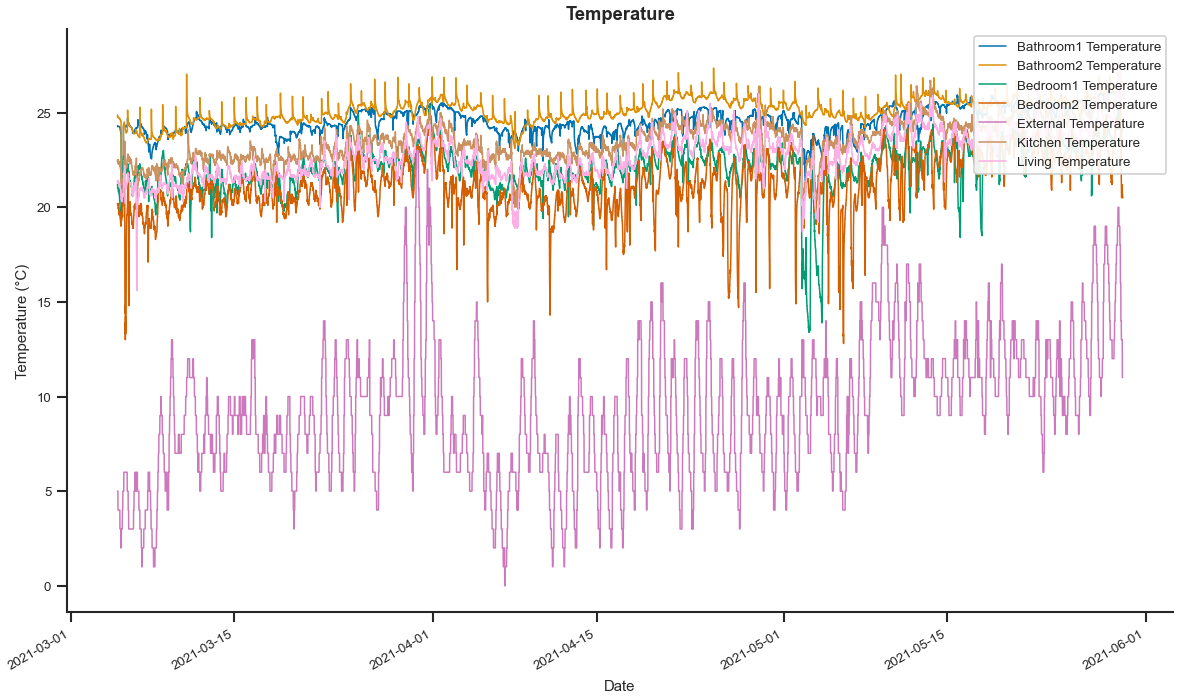

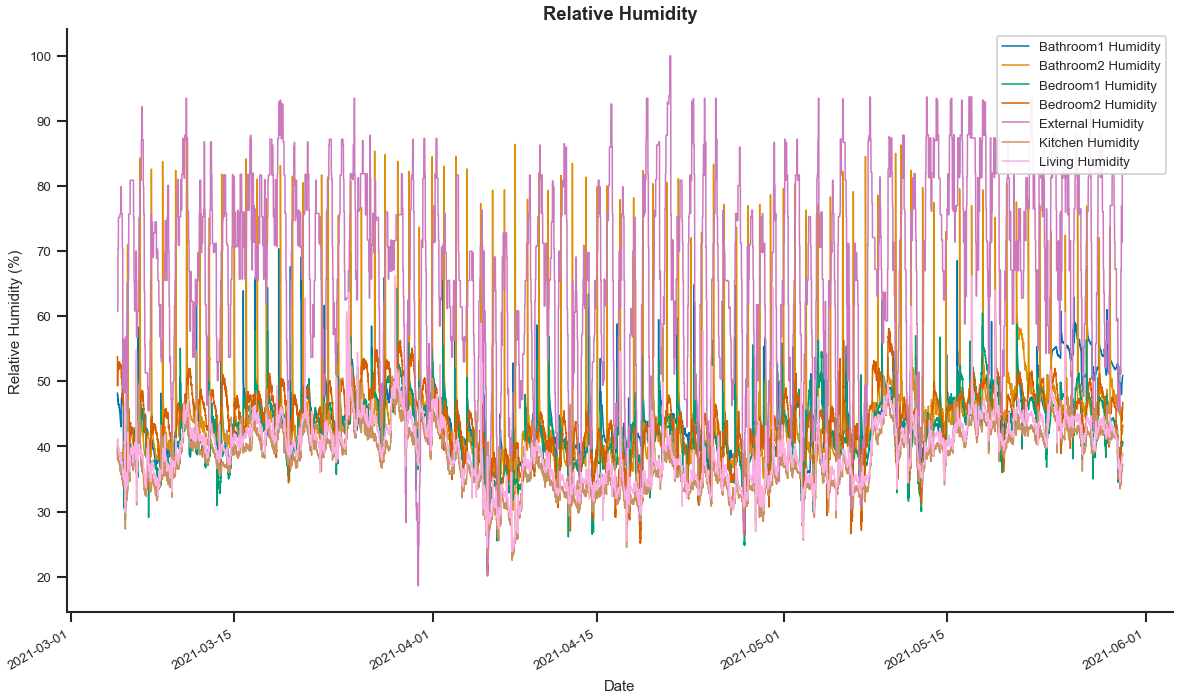

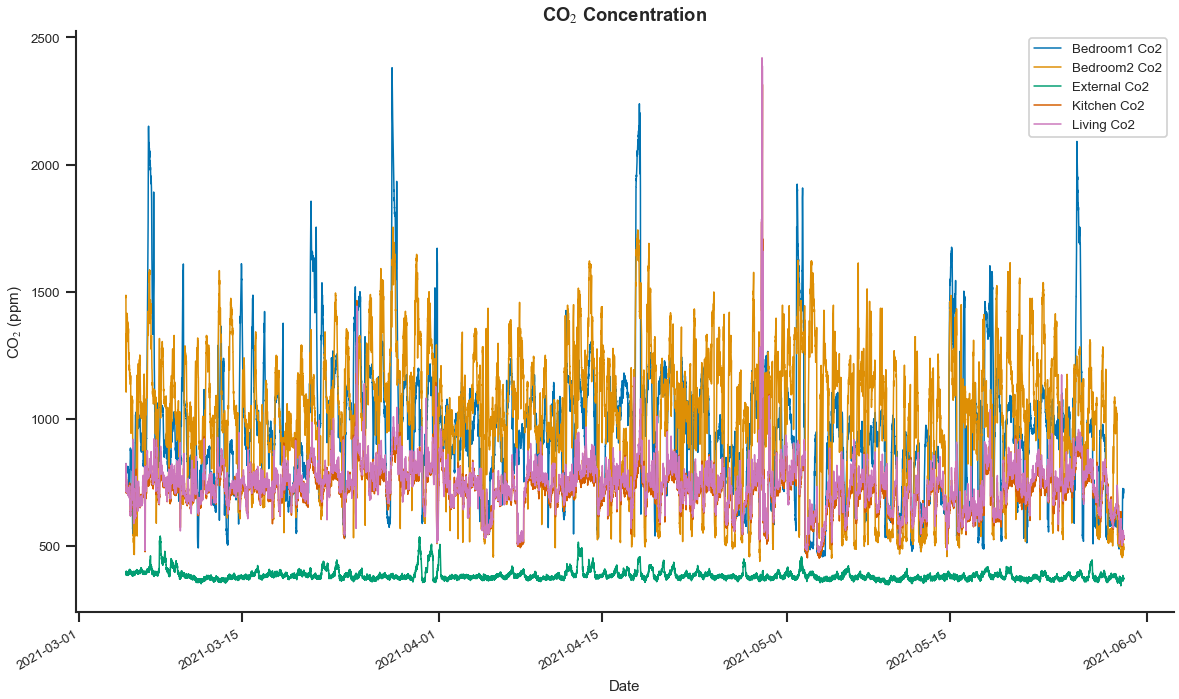

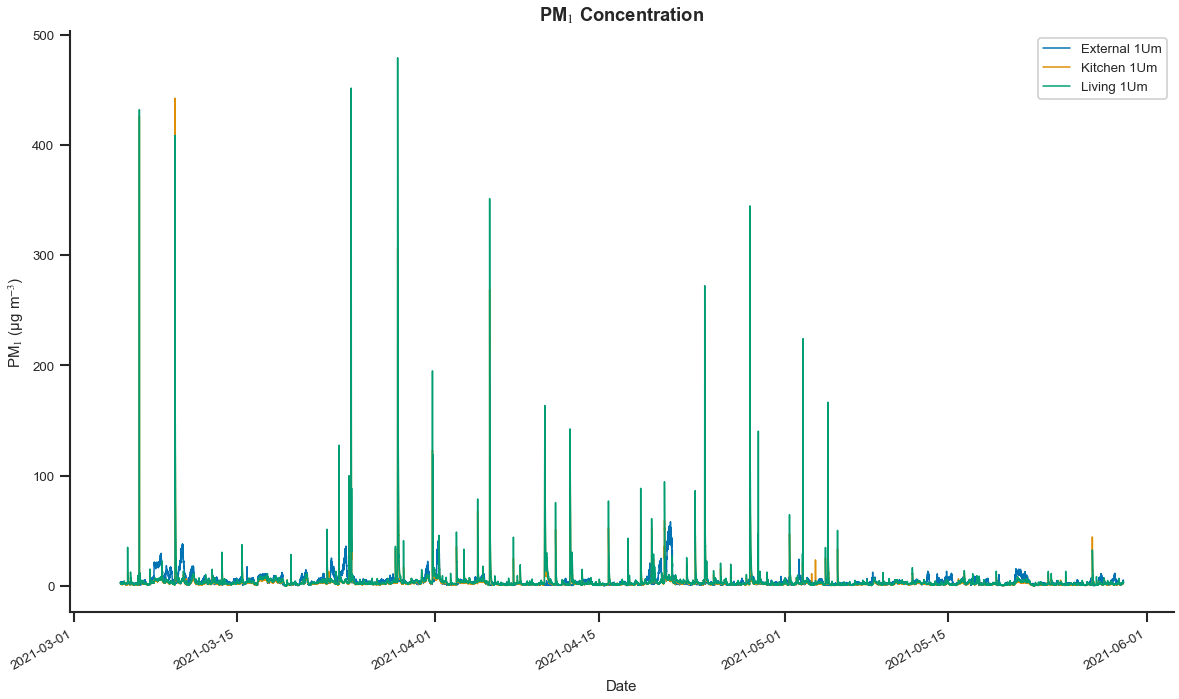

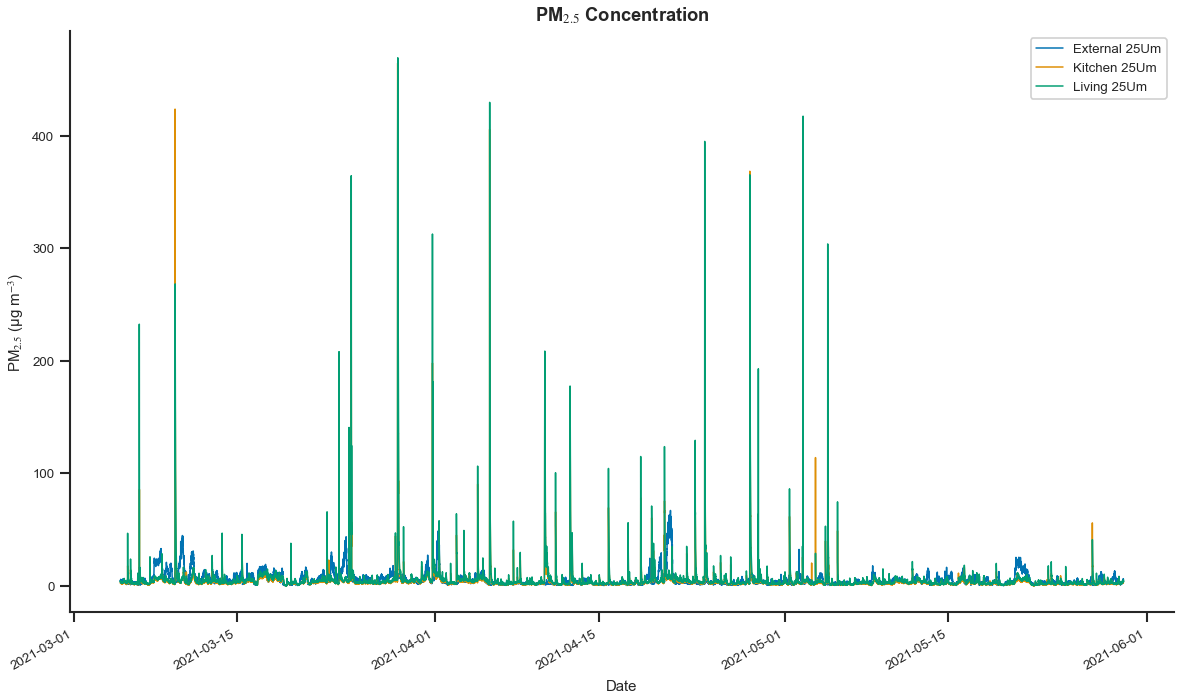

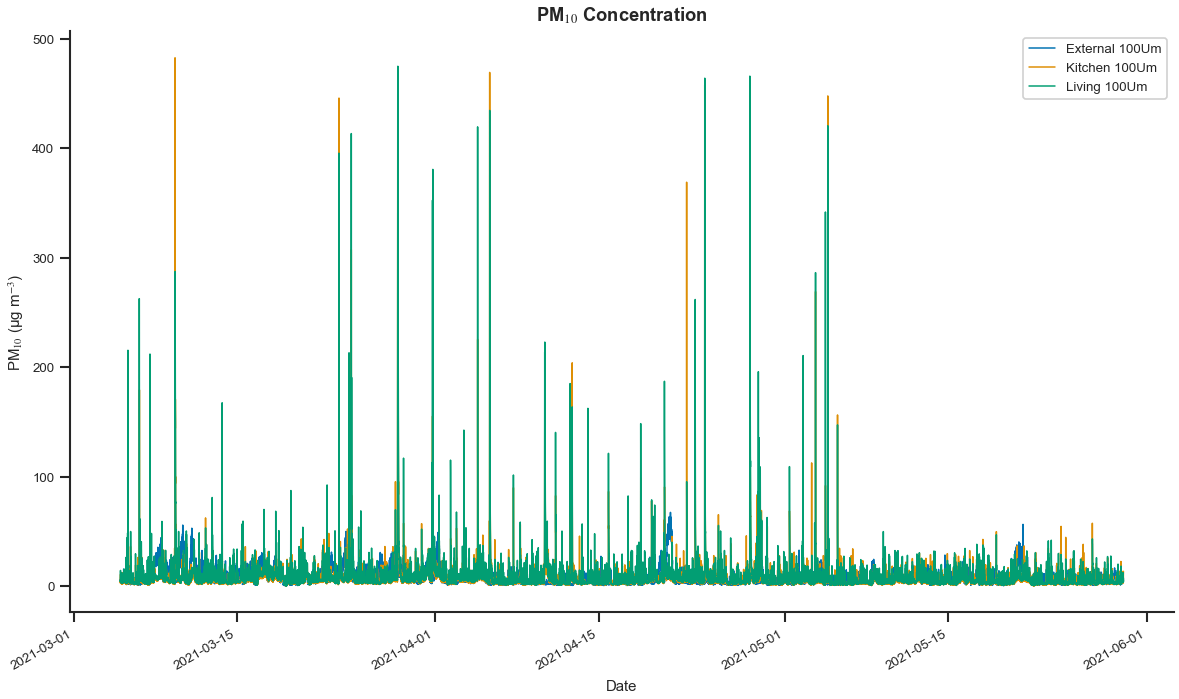

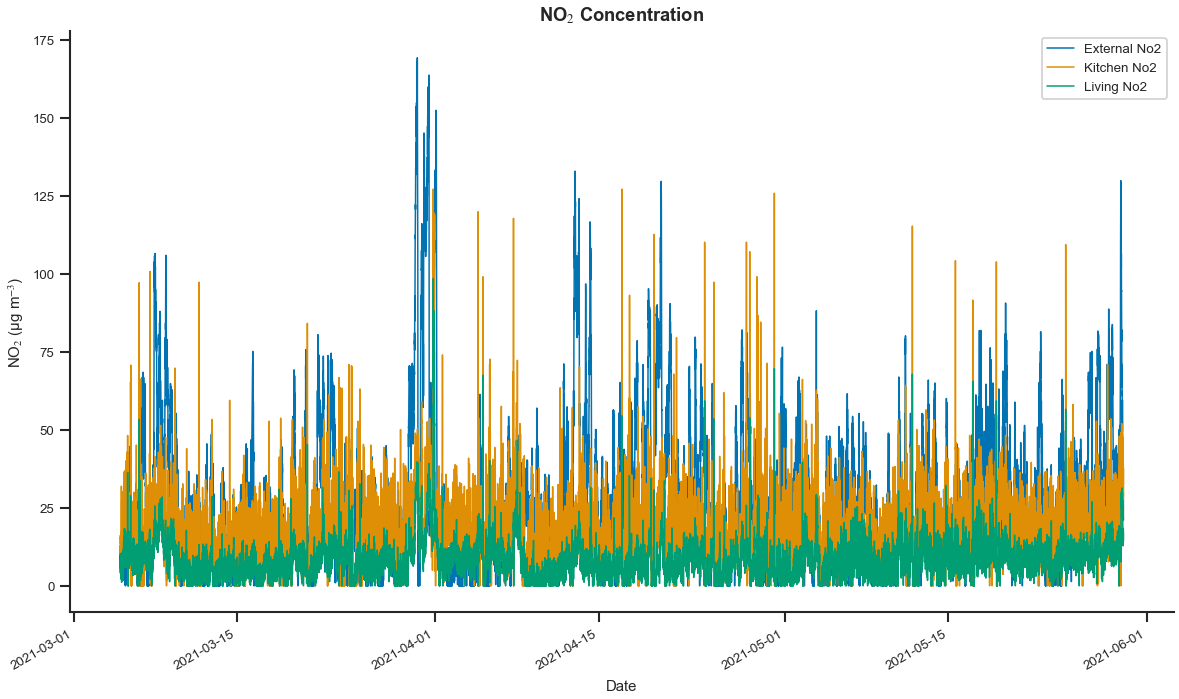

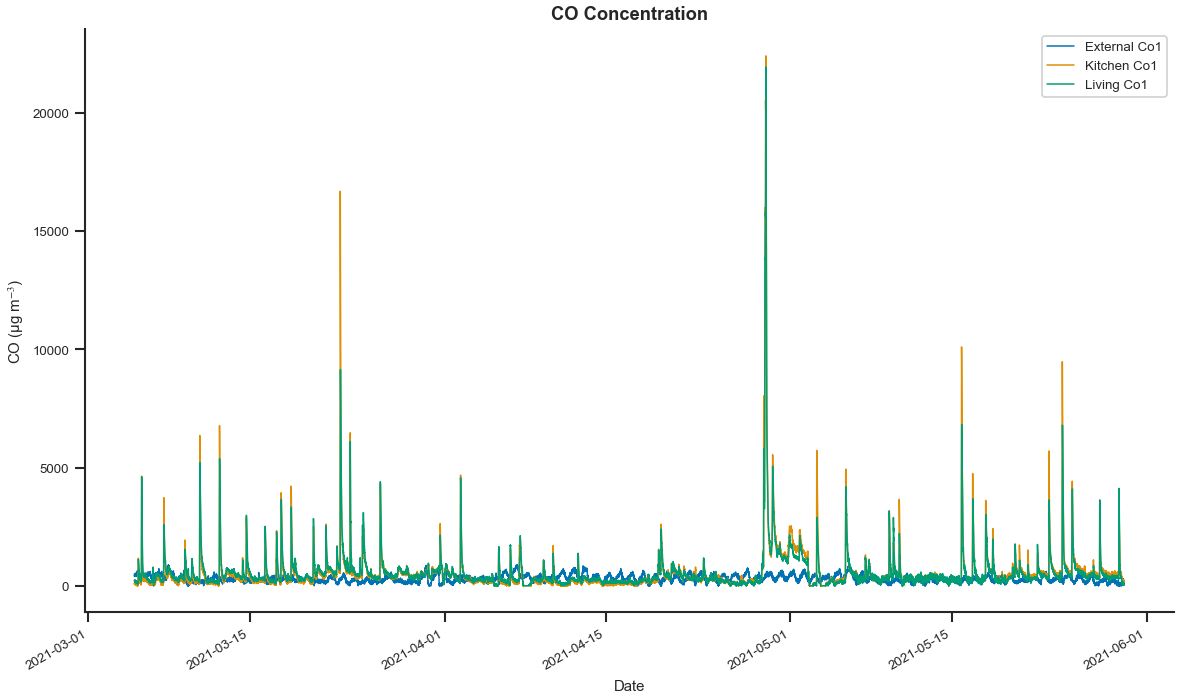

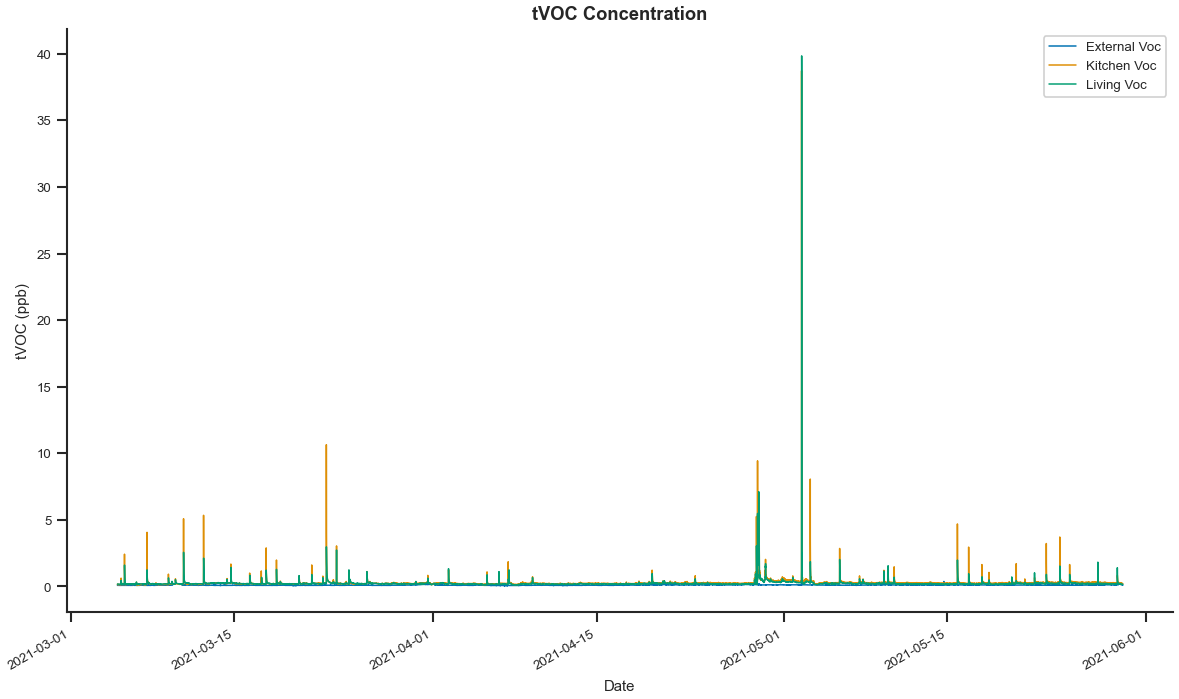

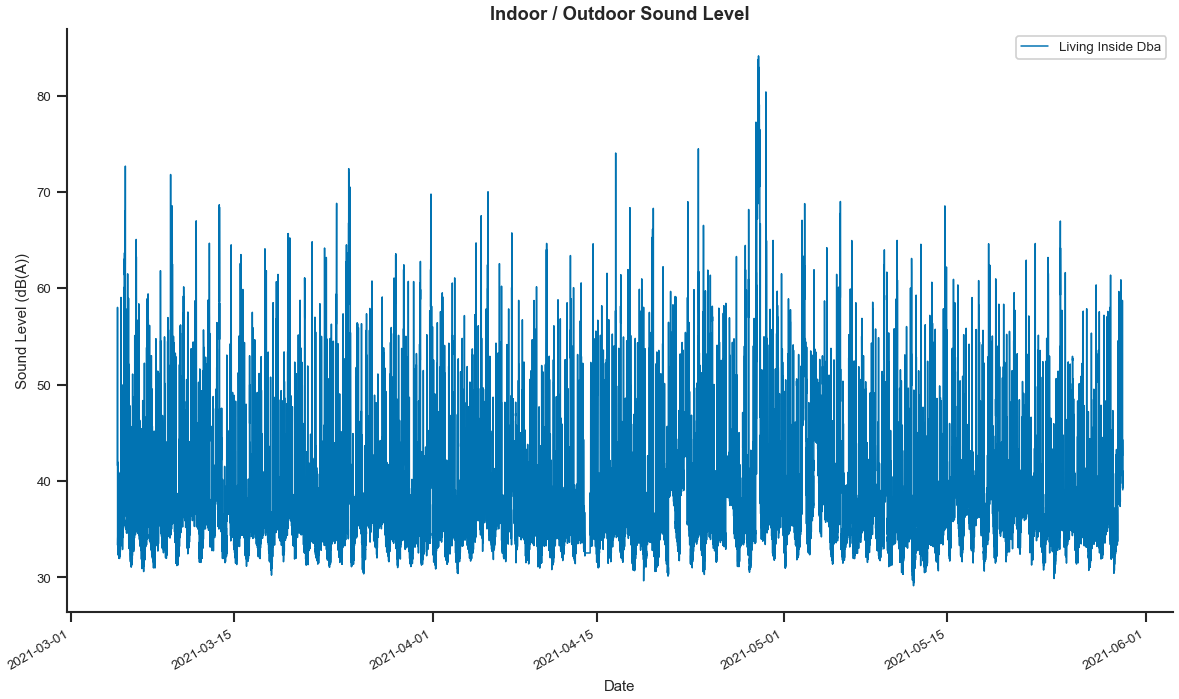

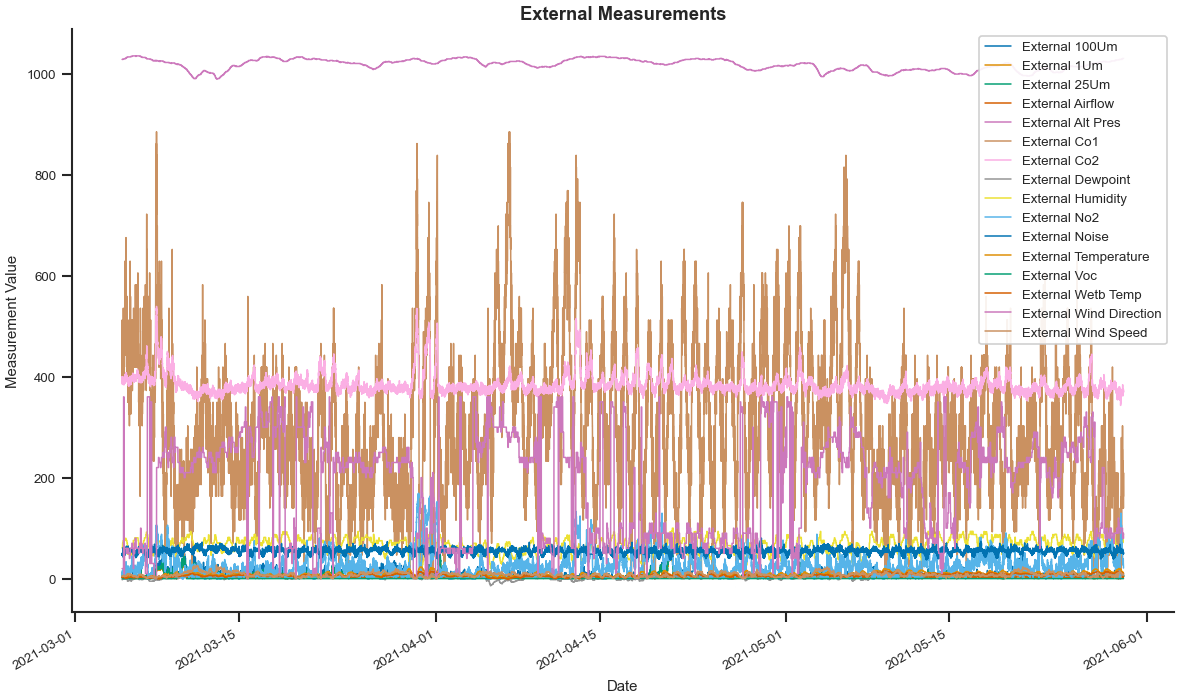

In [37]:
plot_grouped_variables(input_dataframe=p5, input_save=True, save_path="../data/p5_central_london_flat/plots/", figsize=(10, 6), dpi=300)

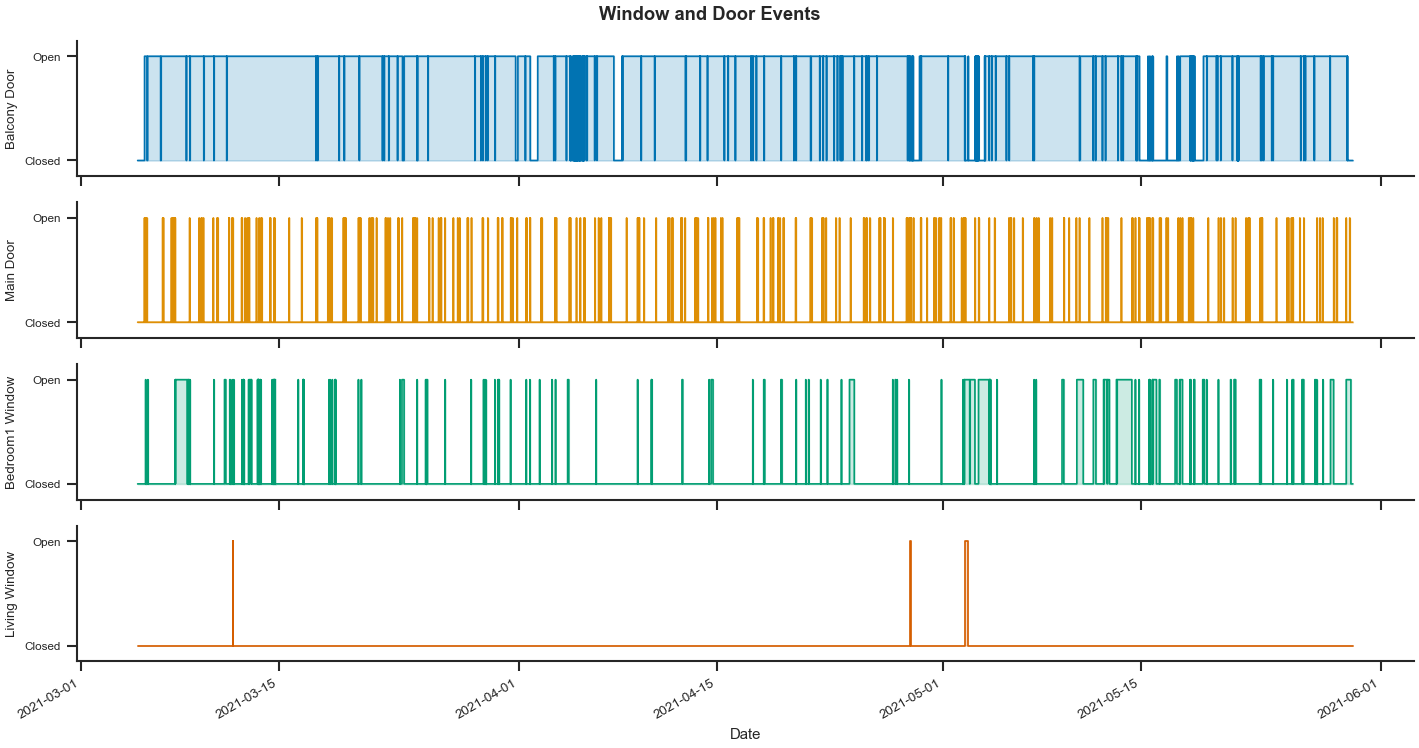

In [38]:
plot_event_timeseries(input_event_dict=p5_event_dict,
                      input_start_date=monitoring_start_date,
                      input_end_date=monitoring_end_date,
                      input_save=True,
                      save_path='../data/p5_central_london_flat/plots/')

## Summary Statistics

In [39]:
p5_continuous_stats, p5_event_stats = summary_statistics(
    input_dataframe=p5,
    input_rooms_and_variables=p5_rooms_and_variables,
    input_event_dict=p5_event_dict,
    input_rooms_and_events=p5_rooms_and_events
)

# Print the number of days of data collected
num_days = (p5.index[-1] - p5.index[0]).days
print(f"Number of days of data collected: {num_days} days")


====    Summary Statistics    ====

--- Continuous Variables ---

  external_100um: n=24769, n_missing=0, mean=6.287, median=4.12
  external_1um: n=24769, n_missing=0, mean=3.938, median=2.48
  external_25um: n=24769, n_missing=0, mean=5.304, median=3.48
  external_airflow: n=24769, n_missing=0, mean=3.432, median=3.4
  external_alt_pres: n=24769, n_missing=0, mean=1017.836, median=1020.0
  external_co1: n=24769, n_missing=0, mean=290.069, median=279.408
  external_co2: n=24769, n_missing=0, mean=384.353, median=379.0
  external_dewpoint: n=24769, n_missing=0, mean=3.049, median=3.0
  external_humidity: n=24769, n_missing=0, mean=66.83, median=69.8
  external_no2: n=24769, n_missing=0, mean=26.752, median=21.229
  external_noise: n=24769, n_missing=0, mean=53.763, median=54.28
  external_temperature: n=24769, n_missing=0, mean=9.294, median=9.0
  external_voc: n=24538, n_missing=231, mean=0.099, median=0.091
  external_wetb_temp: n=24769, n_missing=0, mean=6.655, median=6.5
  external

## Save outputs

In [40]:
save_participant_outputs(
    n=5,
    df=p5,
    event_dict=p5_event_dict,
    rooms_and_variables=p5_rooms_and_variables,
    rooms_and_events=p5_rooms_and_events,
    rooms_list=p5_rooms_list,
    continuous_stats=p5_continuous_stats,
    event_stats=p5_event_stats,
data_dir='../data/p5_central_london_flat')

p5 outputs saved to ../data/p5_central_london_flat/data_processed/p5_outputs.pkl
